In [1]:
import pandas as pd

df = pd.read_csv(
    r"D:\projects\AI-Stock-Analytics-System\data\final\feature_engineered_stock_data.csv"
)

df.head()

,Date,Close,High,Low,Open,Volume,Ticker,Daily_Return,MA5,MA10,...,NIFTY_Close,NIFTY_Return,Relative_Strength,Bank_Relative_Strength,Volume_Ratio,Prev_Close,Gap_Percentage,ATR_Percentage,Bull_Market,Target_Signal_Balanced
0,2008-04-02,621.754211,628.870167,618.566878,620.123469,299209.0,ACC,0.017097,615.431458,602.463446,...,4754.200195,0.003091,-0.292012,-2.473786,0.618517,611.302795,1.442930,4.385541,0,SELL
1,2008-04-03,612.933411,621.161184,604.149660,613.748759,586458.0,ACC,-0.014187,615.987378,607.448297,...,4771.600098,0.003660,-0.380177,0.378572,1.189842,621.754211,-1.287559,4.336049,0,HOLD
2,2008-04-04,615.861389,637.357424,608.634274,637.357424,388972.0,ACC,0.004777,614.845886,611.421350,...,4647.000000,-0.026113,2.616062,2.983536,0.854275,612.933411,3.984774,4.340324,0,HOLD
3,2008-04-07,617.158508,622.643721,608.560113,611.525083,486842.0,ACC,0.002106,615.802063,613.493109,...,4761.200195,0.024575,-2.455397,-4.386639,1.065793,615.861389,-0.704104,4.184831,0,SELL
4,2008-04-08,611.784546,620.420040,600.480597,620.420040,483884.0,ACC,-0.008708,615.898413,614.082391,...,4709.649902,-0.010827,1.074009,-0.452192,1.110288,617.158508,0.528476,4.152850,0,SELL


In [2]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker',
       'Daily_Return', 'MA5', 'MA10', 'MA20', 'MA50', 'EMA20', 'RSI', 'EMA12',
       'EMA26', 'MACD', 'Signal_Line', 'MACD_Histogram', 'Upper_Band',
       'Lower_Band', 'Volatility', 'Lag1', 'Lag2', 'Lag3', 'Target_Close',
       'Future_Return', 'Target_Signal', 'ATR', 'ADX', 'OBV', 'Stochastic',
       'CCI', 'Price_vs_MA20', 'EMA_Diff', 'BB_Width', 'India_VIX',
       'BankNIFTY_Close', 'BankNIFTY_Return', 'NIFTY_Close', 'NIFTY_Return',
       'Relative_Strength', 'Bank_Relative_Strength', 'Volume_Ratio',
       'Prev_Close', 'Gap_Percentage', 'ATR_Percentage', 'Bull_Market',
       'Target_Signal_Balanced'],
      dtype='object')

In [3]:
df["Target_Signal"].value_counts()

Target_Signal
HOLD    167229
SELL    125423
BUY     125423
Name: count, dtype: int64

In [4]:
df["Target_Signal"].value_counts(normalize=True) * 100

Target_Signal
HOLD    39.999761
SELL    30.000120
BUY     30.000120
Name: proportion, dtype: float64

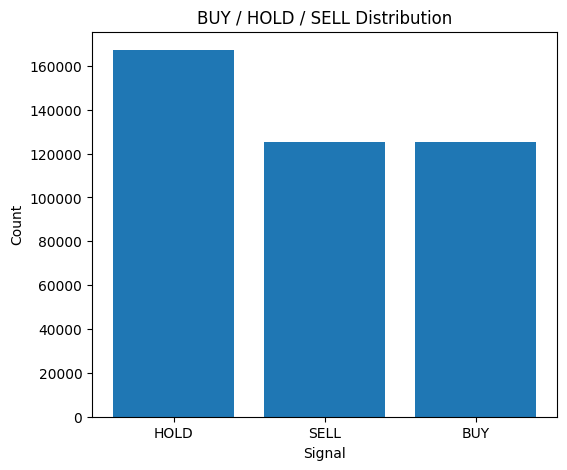

In [5]:
import matplotlib.pyplot as plt

signal_counts = df["Target_Signal"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(
    signal_counts.index,
    signal_counts.values
)

plt.title("BUY / HOLD / SELL Distribution")
plt.xlabel("Signal")
plt.ylabel("Count")

plt.show()

In [6]:
feature_columns = [

    "Close",
    "High",
    "Low",
    "Open",
    "Volume",

    "Daily_Return",

    "MA5",
    "MA10",
    "MA20",
    "MA50",

    "EMA20",
    "EMA12",
    "EMA26",

    "RSI",

    "MACD",
    "Signal_Line",
    "MACD_Histogram",

    "Upper_Band",
    "Lower_Band",

    "Volatility",

    "Lag1",
    "Lag2",
    "Lag3",

    "ATR",
    "ADX",
    "OBV",
    "Stochastic",
    "CCI",

    "Price_vs_MA20",
    "EMA_Diff",
    "BB_Width",
    "NIFTY_Close",
"NIFTY_Return",
"India_VIX",
"BankNIFTY_Close",
"BankNIFTY_Return",
    "Relative_Strength",
"Bank_Relative_Strength",
"Volume_Ratio",
"Gap_Percentage",
"ATR_Percentage",
"Bull_Market"
]

In [7]:
X = df[feature_columns]
y = df["Target_Signal"]

In [8]:
print(df.columns.tolist())

['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker', 'Daily_Return', 'MA5', 'MA10', 'MA20', 'MA50', 'EMA20', 'RSI', 'EMA12', 'EMA26', 'MACD', 'Signal_Line', 'MACD_Histogram', 'Upper_Band', 'Lower_Band', 'Volatility', 'Lag1', 'Lag2', 'Lag3', 'Target_Close', 'Future_Return', 'Target_Signal', 'ATR', 'ADX', 'OBV', 'Stochastic', 'CCI', 'Price_vs_MA20', 'EMA_Diff', 'BB_Width', 'India_VIX', 'BankNIFTY_Close', 'BankNIFTY_Return', 'NIFTY_Close', 'NIFTY_Return', 'Relative_Strength', 'Bank_Relative_Strength', 'Volume_Ratio', 'Prev_Close', 'Gap_Percentage', 'ATR_Percentage', 'Bull_Market', 'Target_Signal_Balanced']


In [9]:
print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (418075, 42)
Target Shape   : (418075,)


In [10]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['BUY' 'HOLD' 'SELL']


In [11]:
mapping = dict(zip(label_encoder.classes_,
                   label_encoder.transform(label_encoder.classes_)))
print(mapping)

{'BUY': np.int64(0), 'HOLD': np.int64(1), 'SELL': np.int64(2)}


In [12]:
from sklearn.model_selection import train_test_split
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    shuffle=False)
print(X_train_cls.shape)
print(X_test_cls.shape)

(334460, 42)
(83615, 42)


In [13]:
from sklearn.preprocessing import StandardScaler

scaler_cls = StandardScaler()

X_train_cls_scaled = scaler_cls.fit_transform(X_train_cls)
X_test_cls_scaled = scaler_cls.transform(X_test_cls)

In [14]:
import pandas as pd

classification_results = pd.DataFrame(
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

classification_results

,Model,Accuracy,Precision,Recall,F1 Score


In [15]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score)
dummy = DummyClassifier(
    strategy="most_frequent")
dummy.fit(
    X_train_cls,
    y_train_cls)
dummy_pred = dummy.predict(
    X_test_cls)
accuracy = accuracy_score(
    y_test_cls,
    dummy_pred)
precision = precision_score(
    y_test_cls,
    dummy_pred,
    average="weighted",
    zero_division=0)
recall = recall_score(
    y_test_cls,
    dummy_pred,
    average="weighted")
f1 = f1_score(
    y_test_cls,
    dummy_pred,
    average="weighted")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.3950248161215093
Precision: 0.15604460535183223
Recall   : 0.3950248161215093
F1 Score : 0.22371588454701788


In [16]:
classification_results.loc[len(classification_results)] = [
    "Baseline",
    accuracy,
    precision,
    recall,
    f1
]

classification_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline,0.395025,0.156045,0.395025,0.223716


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [18]:
logistic = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic.fit(
    X_train_cls_scaled,
    y_train_cls
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [19]:
logistic_pred = logistic.predict(
    X_test_cls_scaled
)

In [20]:
logistic_accuracy = accuracy_score(
    y_test_cls,
    logistic_pred
)

logistic_precision = precision_score(
    y_test_cls,
    logistic_pred,
    average="weighted"
)

logistic_recall = recall_score(
    y_test_cls,
    logistic_pred,
    average="weighted"
)

logistic_f1 = f1_score(
    y_test_cls,
    logistic_pred,
    average="weighted"
)

print("Accuracy :", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall   :", logistic_recall)
print("F1 Score :", logistic_f1)

Accuracy : 0.42059439095856005
Precision: 0.4007982220055373
Recall   : 0.42059439095856005
F1 Score : 0.35872690985341016


In [21]:
classification_results.loc[len(classification_results)] = [
    "Logistic Regression",
    logistic_accuracy,
    logistic_precision,
    logistic_recall,
    logistic_f1
]

classification_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline,0.395025,0.156045,0.395025,0.223716
1,Logistic Regression,0.420594,0.400798,0.420594,0.358727


In [22]:
print(
    classification_report(
        y_test_cls,
        logistic_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

         BUY       0.39      0.14      0.21     25273
        HOLD       0.43      0.82      0.57     33030
        SELL       0.37      0.17      0.23     25312

    accuracy                           0.42     83615
   macro avg       0.40      0.38      0.34     83615
weighted avg       0.40      0.42      0.36     83615



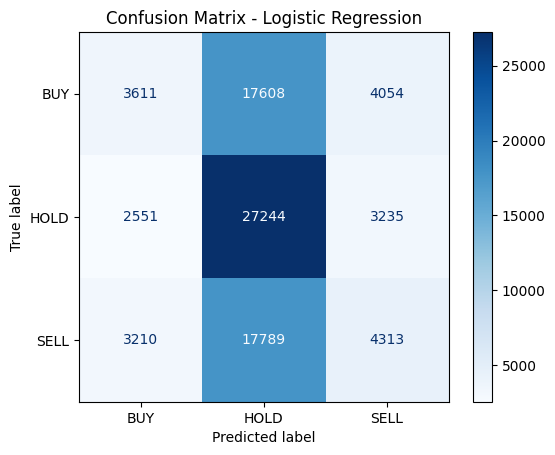

In [23]:
cm = confusion_matrix(
    y_test_cls,
    logistic_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [24]:
import numpy as np
import pandas as pd

importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": np.mean(np.abs(logistic.coef_), axis=0)
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
18,Lower_Band,0.195988
17,Upper_Band,0.167179
2,Low,0.148992
19,Volatility,0.118167
23,ATR,0.104058
1,High,0.094730
34,BankNIFTY_Close,0.080398
31,NIFTY_Close,0.077832
22,Lag3,0.065411
30,BB_Width,0.052965


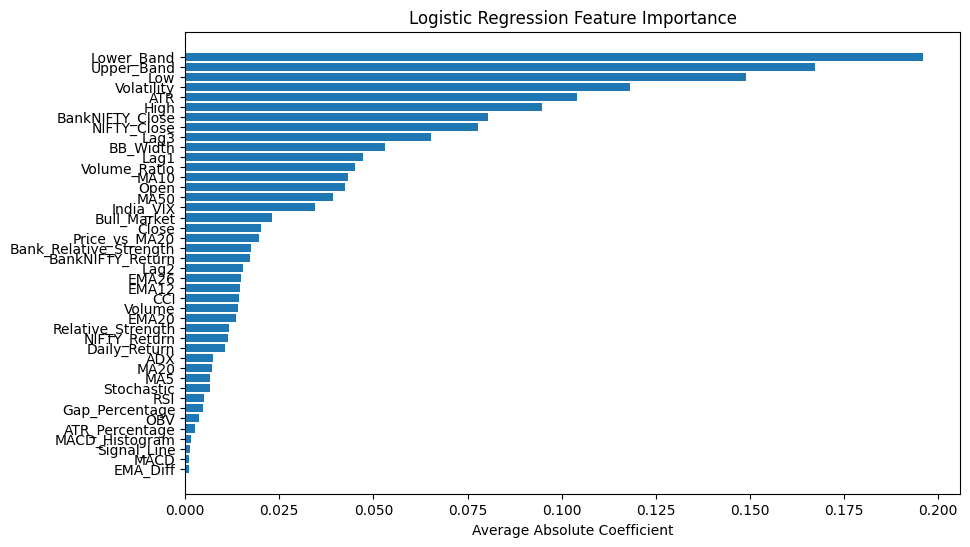

In [25]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Logistic Regression Feature Importance")

plt.xlabel("Average Absolute Coefficient")

plt.gca().invert_yaxis()

plt.show()

Logistic Regression achieved performance very close to the baseline classifier.
    While it slightly improved precision, the overall accuracy and F1-score remained
nearly unchanged. This indicates that the relationship between the technical 
indicators and the BUY/HOLD/SELL target is not adequately captured by a linear 
decision boundary. Therefore, more powerful nonlinear models such as Decision Tree, 
Random Forest, and XGBoost will be evaluated next.

In [26]:
from sklearn.tree import DecisionTreeClassifier

In [27]:
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=10)
decision_tree.fit(
    X_train_cls,
    y_train_cls)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [28]:
decision_tree_pred = decision_tree.predict(
    X_test_cls
)

In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score)
decision_tree_accuracy = accuracy_score(
    y_test_cls,
    decision_tree_pred)
decision_tree_precision = precision_score(
    y_test_cls,
    decision_tree_pred,
    average="weighted")
decision_tree_recall = recall_score(
    y_test_cls,
    decision_tree_pred,
    average="weighted")
decision_tree_f1 = f1_score(
    y_test_cls,
    decision_tree_pred,
    average="weighted")
print("Accuracy :", decision_tree_accuracy)
print("Precision:", decision_tree_precision)
print("Recall   :", decision_tree_recall)
print("F1 Score :", decision_tree_f1)

Accuracy : 0.43065239490522034
Precision: 0.41850781462308106
Recall   : 0.43065239490522034
F1 Score : 0.39891937135174227


In [30]:
classification_results.loc[len(classification_results)] = [
    "Decision Tree",
    decision_tree_accuracy,
    decision_tree_precision,
    decision_tree_recall,
    decision_tree_f1
]

classification_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline,0.395025,0.156045,0.395025,0.223716
1,Logistic Regression,0.420594,0.400798,0.420594,0.358727
2,Decision Tree,0.430652,0.418508,0.430652,0.398919


In [31]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_cls,
        decision_tree_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

         BUY       0.41      0.21      0.27     25273
        HOLD       0.45      0.72      0.56     33030
        SELL       0.38      0.27      0.32     25312

    accuracy                           0.43     83615
   macro avg       0.42      0.40      0.38     83615
weighted avg       0.42      0.43      0.40     83615



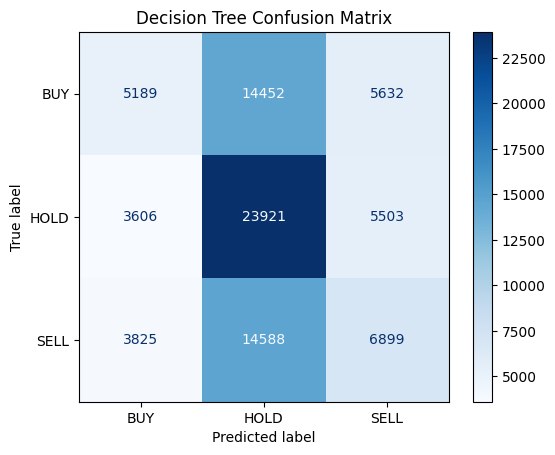

In [32]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

cm = confusion_matrix(
    y_test_cls,
    decision_tree_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")

plt.title("Decision Tree Confusion Matrix")

plt.show()

In [33]:
importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": decision_tree.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
40,ATR_Percentage,0.497003
33,India_VIX,0.063439
35,BankNIFTY_Return,0.045116
32,NIFTY_Return,0.041980
38,Volume_Ratio,0.034584
36,Relative_Strength,0.032594
34,BankNIFTY_Close,0.031923
4,Volume,0.030259
31,NIFTY_Close,0.028525
5,Daily_Return,0.027481


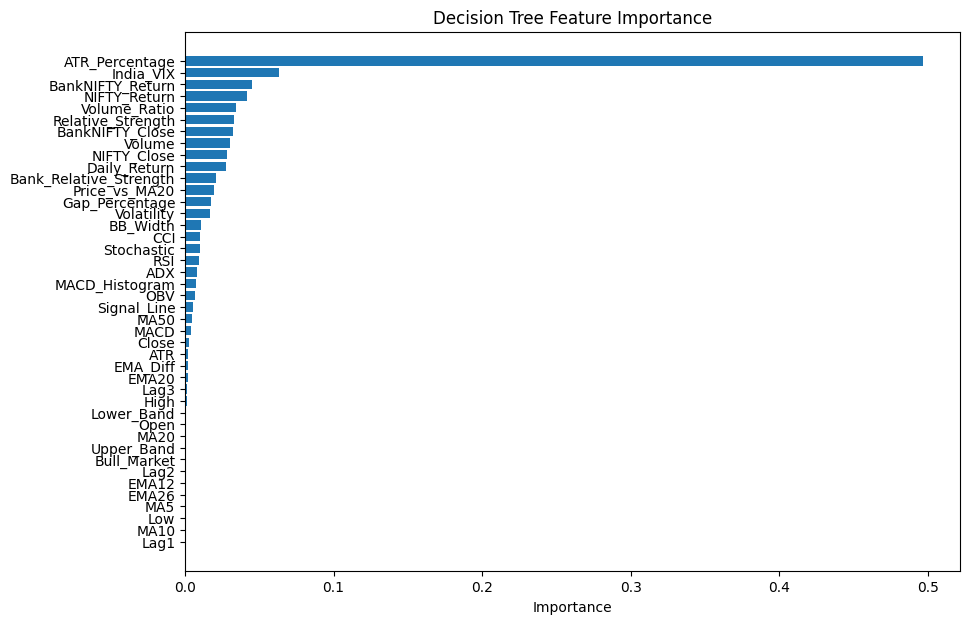

In [34]:
plt.figure(figsize=(10,7))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Decision Tree Feature Importance")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

In [35]:
from sklearn.ensemble import RandomForestClassifier

In [36]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(
    X_train_cls,
    y_train_cls
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [37]:
random_forest_pred = random_forest.predict(
    X_test_cls)

In [38]:
random_forest_accuracy = accuracy_score(
    y_test_cls,
    random_forest_pred)
random_forest_precision = precision_score(
    y_test_cls,
    random_forest_pred,
    average="weighted")
random_forest_recall = recall_score(
    y_test_cls,
    random_forest_pred,
    average="weighted")
random_forest_f1 = f1_score(
    y_test_cls,
    random_forest_pred,
    average="weighted")
print("Accuracy :", random_forest_accuracy)
print("Precision:", random_forest_precision)
print("Recall   :", random_forest_recall)
print("F1 Score :", random_forest_f1)

Accuracy : 0.45864976379836153
Precision: 0.4557897812993822
Recall   : 0.45864976379836153
F1 Score : 0.4468245970161439


In [39]:
classification_results.loc[len(classification_results)] = [
    "Random Forest",
    random_forest_accuracy,
    random_forest_precision,
    random_forest_recall,
    random_forest_f1]
classification_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline,0.395025,0.156045,0.395025,0.223716
1,Logistic Regression,0.420594,0.400798,0.420594,0.358727
2,Decision Tree,0.430652,0.418508,0.430652,0.398919
3,Random Forest,0.458650,0.455790,0.458650,0.446825


In [40]:
print(
    classification_report(
        y_test_cls,
        random_forest_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

         BUY       0.44      0.33      0.38     25273
        HOLD       0.47      0.64      0.54     33030
        SELL       0.45      0.35      0.39     25312

    accuracy                           0.46     83615
   macro avg       0.45      0.44      0.44     83615
weighted avg       0.46      0.46      0.45     83615



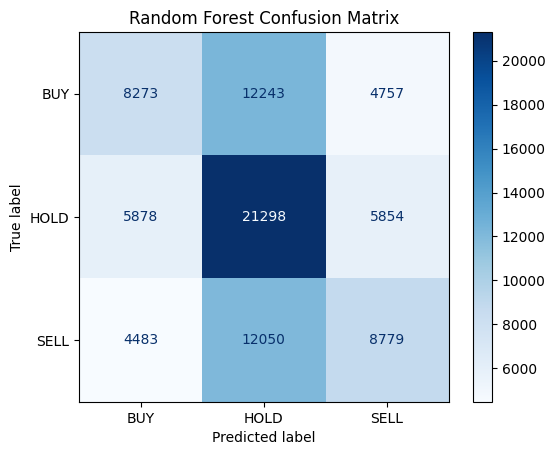

In [41]:
cm = confusion_matrix(
    y_test_cls,
    random_forest_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")

plt.title("Random Forest Confusion Matrix")

plt.show()

In [42]:
importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": random_forest.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
40,ATR_Percentage,0.041558
19,Volatility,0.037990
5,Daily_Return,0.034437
39,Gap_Percentage,0.034100
38,Volume_Ratio,0.033956
30,BB_Width,0.033824
33,India_VIX,0.032972
37,Bank_Relative_Strength,0.032799
36,Relative_Strength,0.032605
4,Volume,0.031928


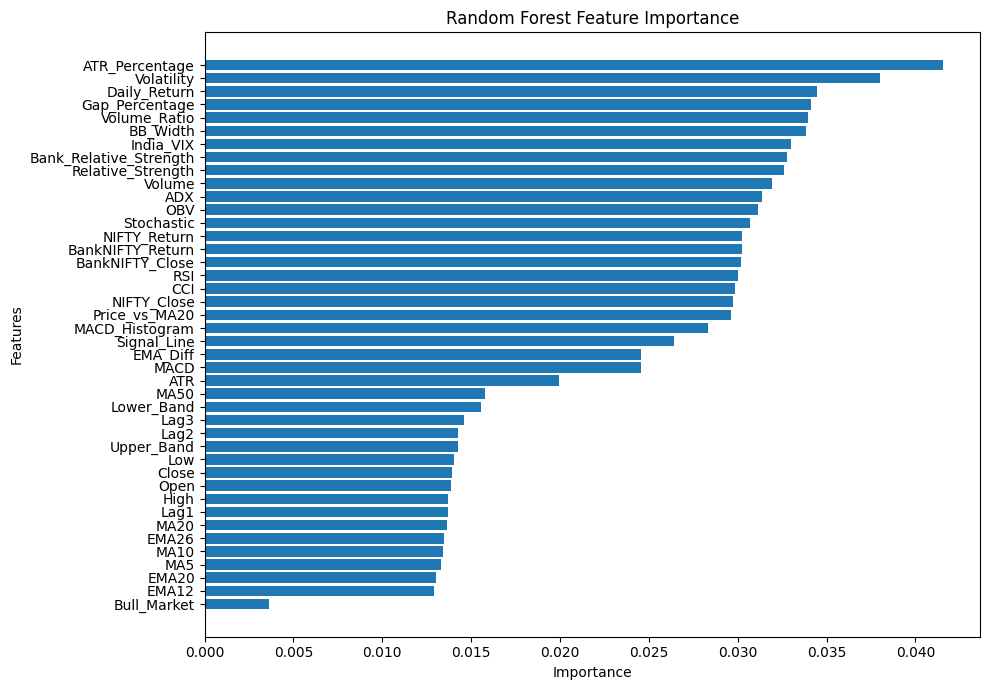

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [44]:
from xgboost import XGBClassifier


In [45]:
xgb_classifier = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

In [46]:
xgb_classifier.fit(
    X_train_cls,
    y_train_cls
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [47]:
xgb_pred = xgb_classifier.predict(
    X_test_cls
)

In [48]:
xgb_accuracy = accuracy_score(
    y_test_cls,
    xgb_pred
)

xgb_precision = precision_score(
    y_test_cls,
    xgb_pred,
    average="weighted"
)

xgb_recall = recall_score(
    y_test_cls,
    xgb_pred,
    average="weighted"
)

xgb_f1 = f1_score(
    y_test_cls,
    xgb_pred,
    average="weighted"
)

print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)

Accuracy : 0.47949530586617234
Precision: 0.4850236298342741
Recall   : 0.47949530586617234
F1 Score : 0.46044634781768884


In [49]:
classification_results.loc[len(classification_results)] = [
    "XGBoost",
    xgb_accuracy,
    xgb_precision,
    xgb_recall,
    xgb_f1
]

classification_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline,0.395025,0.156045,0.395025,0.223716
1,Logistic Regression,0.420594,0.400798,0.420594,0.358727
2,Decision Tree,0.430652,0.418508,0.430652,0.398919
3,Random Forest,0.458650,0.455790,0.458650,0.446825
4,XGBoost,0.479495,0.485024,0.479495,0.460446


In [50]:
print(
    classification_report(
        y_test_cls,
        xgb_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

         BUY       0.50      0.28      0.36     25273
        HOLD       0.47      0.71      0.57     33030
        SELL       0.49      0.38      0.43     25312

    accuracy                           0.48     83615
   macro avg       0.49      0.46      0.45     83615
weighted avg       0.49      0.48      0.46     83615



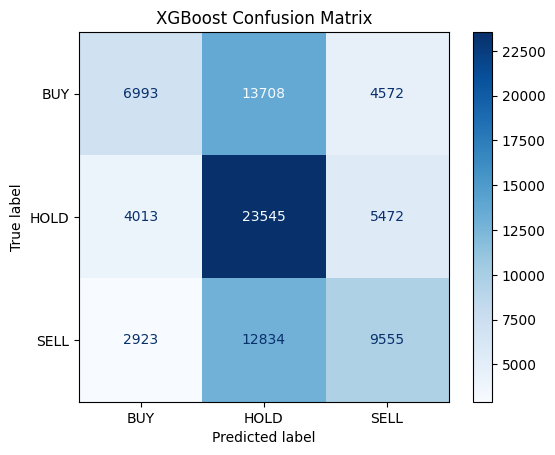

In [51]:
cm = confusion_matrix(
    y_test_cls,
    xgb_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")

plt.title("XGBoost Confusion Matrix")

plt.show()

In [52]:
importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": xgb_classifier.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
40,ATR_Percentage,0.205214
19,Volatility,0.043429
33,India_VIX,0.038948
32,NIFTY_Return,0.037492
35,BankNIFTY_Return,0.037233
34,BankNIFTY_Close,0.035164
36,Relative_Strength,0.033136
31,NIFTY_Close,0.032740
41,Bull_Market,0.032015
30,BB_Width,0.030830


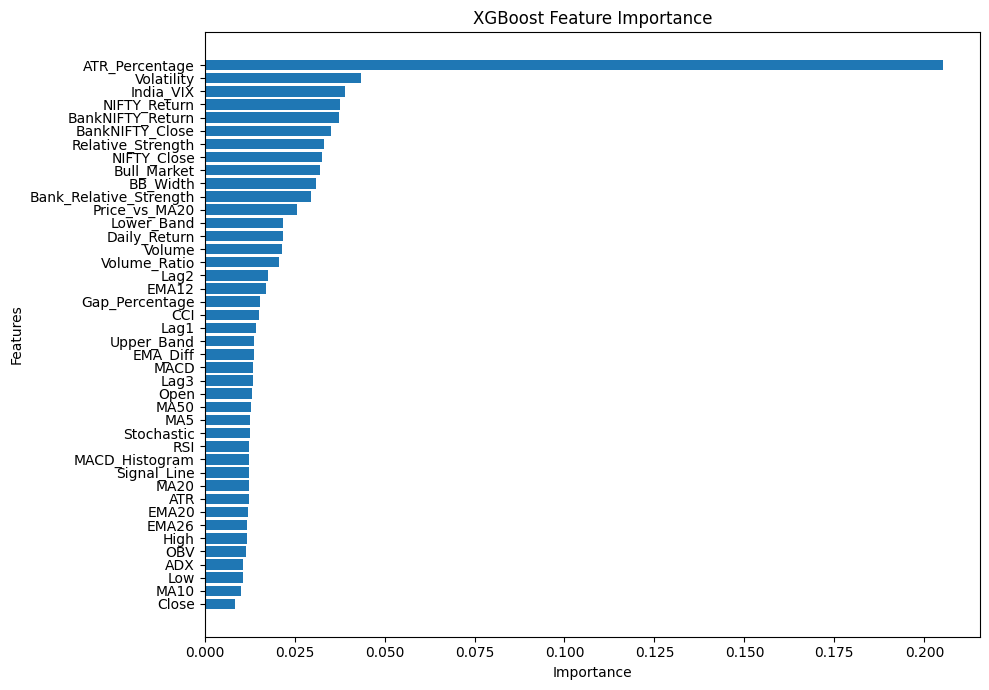

In [53]:
plt.figure(figsize=(10,7))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [54]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train_cls)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_cls
)

class_weights = dict(zip(classes, class_weights))

print(class_weights)

{np.int64(0): np.float64(1.1131968713596272), np.int64(1): np.float64(0.8307563146272824), np.int64(2): np.float64(1.113630536770851)}


In [55]:
sample_weights = np.array(
    [class_weights[label] for label in y_train_cls]
)

In [56]:
from xgboost import XGBClassifier

xgb_classifier_balanced = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_classifier_balanced.fit(
    X_train_cls,
    y_train_cls,
    sample_weight=sample_weights
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [57]:
xgb_balanced_pred = xgb_classifier_balanced.predict(
    X_test_cls
)

In [58]:
xgb_balanced_accuracy = accuracy_score(
    y_test_cls,
    xgb_balanced_pred
)

xgb_balanced_precision = precision_score(
    y_test_cls,
    xgb_balanced_pred,
    average="weighted"
)

xgb_balanced_recall = recall_score(
    y_test_cls,
    xgb_balanced_pred,
    average="weighted"
)

xgb_balanced_f1 = f1_score(
    y_test_cls,
    xgb_balanced_pred,
    average="weighted"
)

print("Accuracy :", xgb_balanced_accuracy)
print("Precision:", xgb_balanced_precision)
print("Recall   :", xgb_balanced_recall)
print("F1 Score :", xgb_balanced_f1)

Accuracy : 0.4731567302517491
Precision: 0.47590518882830624
Recall   : 0.4731567302517491
F1 Score : 0.4716481473537985


In [59]:
print(
    classification_report(
        y_test_cls,
        xgb_balanced_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

         BUY       0.47      0.39      0.42     25273
        HOLD       0.51      0.49      0.50     33030
        SELL       0.44      0.54      0.49     25312

    accuracy                           0.47     83615
   macro avg       0.47      0.47      0.47     83615
weighted avg       0.48      0.47      0.47     83615



In [60]:
tuning_results = pd.DataFrame(
    columns=[
        "Configuration",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

tuning_results

,Configuration,Accuracy,Precision,Recall,F1 Score


In [61]:
tuning_results.loc[len(tuning_results)] = [
    "Default",
    xgb_accuracy,
    xgb_precision,
    xgb_recall,
    xgb_f1
]

tuning_results

,Configuration,Accuracy,Precision,Recall,F1 Score
0,Default,0.479495,0.485024,0.479495,0.460446


In [62]:
from xgboost import XGBClassifier

xgb_tuned_1 = XGBClassifier(
    objective="multi:softprob",
    num_class=3,

    n_estimators=300,
    learning_rate=0.05,

    max_depth=4,
    min_child_weight=3,

    subsample=0.9,
    colsample_bytree=0.9,

    gamma=0.2,

    reg_alpha=0.1,
    reg_lambda=3,

    random_state=42,
    eval_metric="mlogloss",

    n_jobs=-1
)

xgb_tuned_1.fit(
    X_train_cls,
    y_train_cls
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [63]:
pred = xgb_tuned_1.predict(X_test_cls)

acc = accuracy_score(y_test_cls, pred)

prec = precision_score(
    y_test_cls,
    pred,
    average="weighted"
)

rec = recall_score(
    y_test_cls,
    pred,
    average="weighted"
)

f1 = f1_score(
    y_test_cls,
    pred,
    average="weighted"
)

print(acc)
print(prec)
print(rec)
print(f1)

0.4632661603779226
0.46322560949128594
0.4632661603779226
0.4397210504129099


In [64]:
tuning_results.loc[len(tuning_results)] = [
    "Config 1",
    acc,
    prec,
    rec,
    f1
]

tuning_results

,Configuration,Accuracy,Precision,Recall,F1 Score
0,Default,0.479495,0.485024,0.479495,0.460446
1,Config 1,0.463266,0.463226,0.463266,0.439721


In [65]:
xgb_tuned_2 = XGBClassifier(
    objective="multi:softprob",
    num_class=3,

    n_estimators=500,
    learning_rate=0.03,

    max_depth=8,

    min_child_weight=1,

    subsample=0.8,
    colsample_bytree=0.8,

    gamma=0,

    random_state=42,
    eval_metric="mlogloss",

    n_jobs=-1
)

xgb_tuned_2.fit(
    X_train_cls,
    y_train_cls
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [66]:
pred = xgb_tuned_2.predict(X_test_cls)

acc = accuracy_score(y_test_cls, pred)

prec = precision_score(
    y_test_cls,
    pred,
    average="weighted"
)

rec = recall_score(
    y_test_cls,
    pred,
    average="weighted"
)

f1 = f1_score(
    y_test_cls,
    pred,
    average="weighted"
)

print(acc)
print(prec)
print(rec)
print(f1)

0.5093822878670095
0.5191121519325028
0.5093822878670095
0.498525815200379


In [67]:
tuning_results.loc[len(tuning_results)] = [
    "Config 2",
    acc,
    prec,
    rec,
    f1
]

tuning_results

,Configuration,Accuracy,Precision,Recall,F1 Score
0,Default,0.479495,0.485024,0.479495,0.460446
1,Config 1,0.463266,0.463226,0.463266,0.439721
2,Config 2,0.509382,0.519112,0.509382,0.498526


In [68]:
xgb_tuned_3 = XGBClassifier(
    objective="multi:softprob",
    num_class=3,

    n_estimators=400,

    learning_rate=0.05,

    max_depth=5,

    min_child_weight=5,

    gamma=0.3,

    subsample=0.7,

    colsample_bytree=0.7,

    reg_alpha=1,

    reg_lambda=5,

    random_state=42,

    eval_metric="mlogloss",

    n_jobs=-1
)

xgb_tuned_3.fit(
    X_train_cls,
    y_train_cls
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [69]:
pred = xgb_tuned_3.predict(X_test_cls)

acc = accuracy_score(y_test_cls, pred)

prec = precision_score(
    y_test_cls,
    pred,
    average="weighted"
)

rec = recall_score(
    y_test_cls,
    pred,
    average="weighted"
)

f1 = f1_score(
    y_test_cls,
    pred,
    average="weighted"
)

print(acc)
print(prec)
print(rec)
print(f1)

0.48059558691622317
0.4876631889730788
0.48059558691622317
0.4622222736066251


In [70]:
tuning_results.loc[len(tuning_results)] = [
    "Config 3",
    acc,
    prec,
    rec,
    f1
]

tuning_results

,Configuration,Accuracy,Precision,Recall,F1 Score
0,Default,0.479495,0.485024,0.479495,0.460446
1,Config 1,0.463266,0.463226,0.463266,0.439721
2,Config 2,0.509382,0.519112,0.509382,0.498526
3,Config 3,0.480596,0.487663,0.480596,0.462222


In [71]:
xgb_tuned_4 = XGBClassifier(
    objective="multi:softprob",
    num_class=3,

    n_estimators=1000,

    learning_rate=0.01,

    max_depth=4,

    min_child_weight=2,

    subsample=0.8,

    colsample_bytree=0.8,

    gamma=0.1,

    random_state=42,

    eval_metric="mlogloss",

    n_jobs=-1
)

xgb_tuned_4.fit(
    X_train_cls,
    y_train_cls
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [72]:
pred = xgb_tuned_4.predict(X_test_cls)

acc = accuracy_score(y_test_cls, pred)

prec = precision_score(
    y_test_cls,
    pred,
    average="weighted"
)

rec = recall_score(
    y_test_cls,
    pred,
    average="weighted"
)

f1 = f1_score(
    y_test_cls,
    pred,
    average="weighted"
)

print(acc)
print(prec)
print(rec)
print(f1)

0.4566166357710937
0.45467758710208134
0.4566166357710937
0.4282974887779423


In [73]:
tuning_results.loc[len(tuning_results)] = [
    "Config 4",
    acc,
    prec,
    rec,
    f1
]

tuning_results

,Configuration,Accuracy,Precision,Recall,F1 Score
0,Default,0.479495,0.485024,0.479495,0.460446
1,Config 1,0.463266,0.463226,0.463266,0.439721
2,Config 2,0.509382,0.519112,0.509382,0.498526
3,Config 3,0.480596,0.487663,0.480596,0.462222
4,Config 4,0.456617,0.454678,0.456617,0.428297


In [74]:
pip install catboost

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: catboost in C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages (1.2.10)




[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [75]:
from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [76]:
catboost = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    loss_function="MultiClass",
    early_stopping_rounds=50,
    verbose=100
)

catboost.fit(
    X_train_cls,
    y_train_cls,
    eval_set=(X_test_cls, y_test_cls)
)

0:	learn: 1.0953438	test: 1.0957737	best: 1.0957737 (0)	total: 325ms	remaining: 2m 42s
100:	learn: 1.0554607	test: 1.0618821	best: 1.0618821 (100)	total: 14.3s	remaining: 56.3s
200:	learn: 1.0481853	test: 1.0561649	best: 1.0561649 (200)	total: 29.9s	remaining: 44.5s
300:	learn: 1.0414055	test: 1.0505008	best: 1.0505008 (300)	total: 42.9s	remaining: 28.4s
400:	learn: 1.0353597	test: 1.0459655	best: 1.0459655 (400)	total: 55.8s	remaining: 13.8s
499:	learn: 1.0299061	test: 1.0419579	best: 1.0419579 (499)	total: 1m 8s	remaining: 0us

bestTest = 1.041957881
bestIteration = 499



CatBoostClassifier(depth=6, early_stopping_rounds=50, iterations=500, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=100)

In [77]:
catboost_pred = catboost.predict(X_test_cls)

# Convert predictions to 1D integer array
catboost_pred = catboost_pred.flatten().astype(int)

In [78]:
catboost_accuracy = accuracy_score(
    y_test_cls,
    catboost_pred
)

catboost_precision = precision_score(
    y_test_cls,
    catboost_pred,
    average="weighted"
)

catboost_recall = recall_score(
    y_test_cls,
    catboost_pred,
    average="weighted"
)

catboost_f1 = f1_score(
    y_test_cls,
    catboost_pred,
    average="weighted"
)

print("Accuracy :", catboost_accuracy)
print("Precision:", catboost_precision)
print("Recall   :", catboost_recall)
print("F1 Score :", catboost_f1)

Accuracy : 0.4702146744005262
Precision: 0.4722000316032826
Recall   : 0.4702146744005262
F1 Score : 0.44880730495490295


In [79]:
classification_results.loc[len(classification_results)] = [
    "CatBoost",
    catboost_accuracy,
    catboost_precision,
    catboost_recall,
    catboost_f1
]

classification_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline,0.395025,0.156045,0.395025,0.223716
1,Logistic Regression,0.420594,0.400798,0.420594,0.358727
2,Decision Tree,0.430652,0.418508,0.430652,0.398919
3,Random Forest,0.458650,0.455790,0.458650,0.446825
4,XGBoost,0.479495,0.485024,0.479495,0.460446
5,CatBoost,0.470215,0.472200,0.470215,0.448807


In [80]:
print(
    classification_report(
        y_test_cls,
        catboost_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

         BUY       0.48      0.26      0.34     25273
        HOLD       0.47      0.72      0.57     33030
        SELL       0.47      0.35      0.40     25312

    accuracy                           0.47     83615
   macro avg       0.47      0.45      0.44     83615
weighted avg       0.47      0.47      0.45     83615



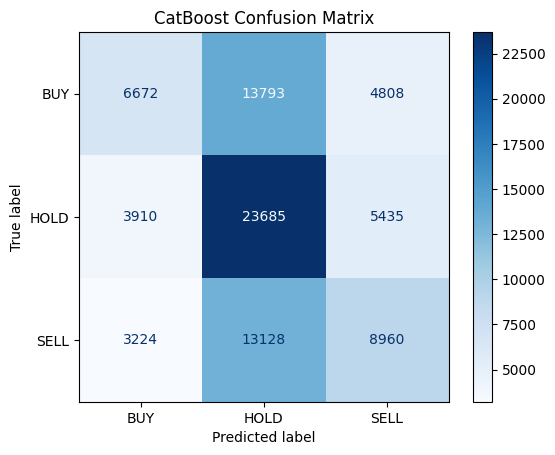

In [81]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test_cls,
    catboost_pred,
    display_labels=label_encoder.classes_,
    cmap="Blues"
)

plt.title("CatBoost Confusion Matrix")
plt.show()

In [82]:
feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": catboost.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
33,India_VIX,13.338960
34,BankNIFTY_Close,12.047582
31,NIFTY_Close,11.138759
32,NIFTY_Return,10.393675
40,ATR_Percentage,10.346908
35,BankNIFTY_Return,9.672263
36,Relative_Strength,5.949086
37,Bank_Relative_Strength,5.578038
41,Bull_Market,2.826154
5,Daily_Return,2.184444


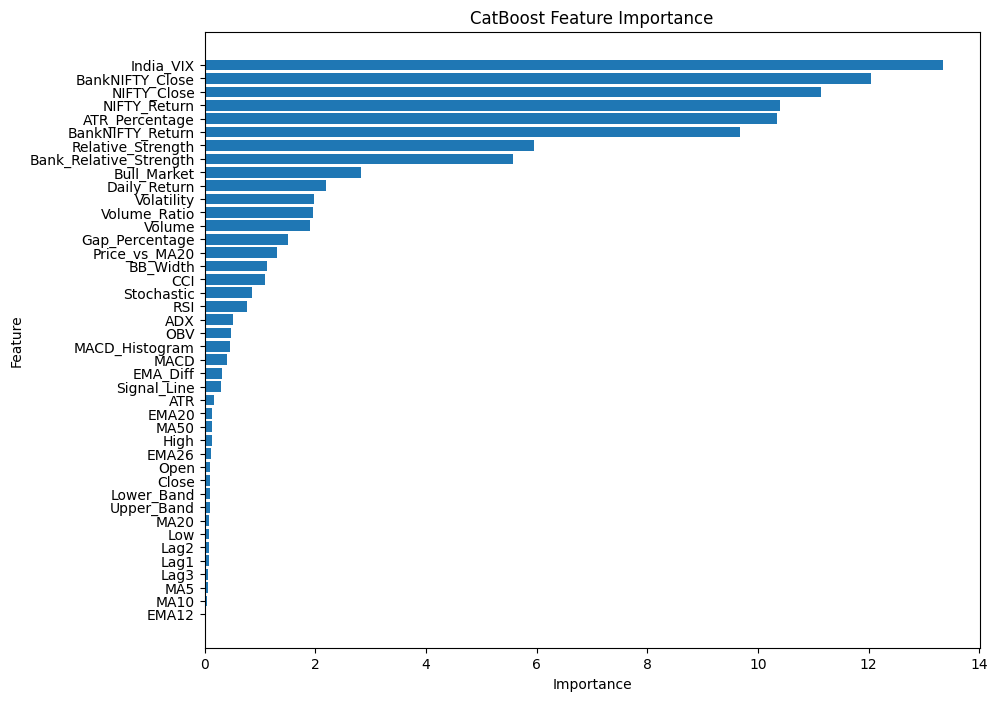

In [83]:
plt.figure(figsize=(10,8))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("CatBoost Feature Importance")

plt.show()

In [84]:
pip install lightgbm


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [85]:
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

In [86]:
lgbm = LGBMClassifier(

    objective="multiclass",

    num_class=3,

    n_estimators=500,

    learning_rate=0.05,

    max_depth=6,

    num_leaves=31,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42

)

lgbm.fit(
    X_train_cls,
    y_train_cls
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.055360 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10457
[LightGBM] [Info] Number of data points in the train set: 334460, number of used features: 42
[LightGBM] [Info] Start training from score -1.205848
[LightGBM] [Info] Start training from score -0.913194
[LightGBM] [Info] Start training from score -1.206238
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] N

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [87]:
lgbm_pred = lgbm.predict(X_test_cls)

In [88]:
lgbm_accuracy = accuracy_score(
    y_test_cls,
    lgbm_pred
)

lgbm_precision = precision_score(
    y_test_cls,
    lgbm_pred,
    average="weighted"
)

lgbm_recall = recall_score(
    y_test_cls,
    lgbm_pred,
    average="weighted"
)

lgbm_f1 = f1_score(
    y_test_cls,
    lgbm_pred,
    average="weighted"
)

print("Accuracy :", lgbm_accuracy)
print("Precision:", lgbm_precision)
print("Recall   :", lgbm_recall)
print("F1 Score :", lgbm_f1)

Accuracy : 0.492005023022185
Precision: 0.4982883386757615
Recall   : 0.492005023022185
F1 Score : 0.4782821858165606


In [89]:
classification_results.loc[len(classification_results)] = [
    "LightGBM",
    lgbm_accuracy,
    lgbm_precision,
    lgbm_recall,
    lgbm_f1
]

classification_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline,0.395025,0.156045,0.395025,0.223716
1,Logistic Regression,0.420594,0.400798,0.420594,0.358727
2,Decision Tree,0.430652,0.418508,0.430652,0.398919
3,Random Forest,0.458650,0.455790,0.458650,0.446825
4,XGBoost,0.479495,0.485024,0.479495,0.460446
5,CatBoost,0.470215,0.472200,0.470215,0.448807
6,LightGBM,0.492005,0.498288,0.492005,0.478282


<Figure size 700x600 with 0 Axes>

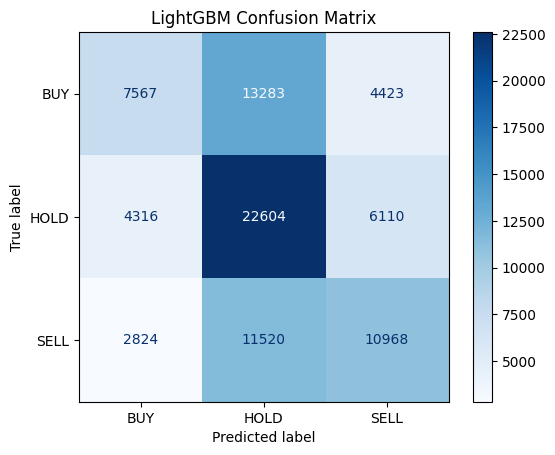

In [90]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions
y_pred = lgbm.predict(X_test_cls)

# Plot Confusion Matrix
plt.figure(figsize=(7,6))

ConfusionMatrixDisplay.from_predictions(
    y_test_cls,
    y_pred,
    display_labels=label_encoder.classes_,
    cmap="Blues",
    values_format="d"
)

plt.title("LightGBM Confusion Matrix")
plt.grid(False)
plt.show()

In [91]:
print(
    classification_report(
        y_test_cls,
        catboost_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

         BUY       0.48      0.26      0.34     25273
        HOLD       0.47      0.72      0.57     33030
        SELL       0.47      0.35      0.40     25312

    accuracy                           0.47     83615
   macro avg       0.47      0.45      0.44     83615
weighted avg       0.47      0.47      0.45     83615



In [92]:
from lightgbm import LGBMClassifier
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

In [93]:
classes = np.unique(y_train_cls)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_cls
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(1.1131968713596272), np.int64(1): np.float64(0.8307563146272824), np.int64(2): np.float64(1.113630536770851)}


In [94]:
lgbm_balanced = LGBMClassifier(
    objective="multiclass",
    num_class=3,

    n_estimators=500,
    learning_rate=0.05,

    max_depth=6,
    num_leaves=31,

    subsample=0.8,
    colsample_bytree=0.8,

    class_weight=class_weights,

    random_state=42
)

lgbm_balanced.fit(
    X_train_cls,
    y_train_cls
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.052107 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10457
[LightGBM] [Info] Number of data points in the train set: 334460, number of used features: 42
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] N

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,"{np.int64(0): np.float64(1.1131968713596272), np.int64(1): np.float64(0.8307563146272824), np.int64(2): np.float64(1.113630536770851)}"
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [95]:
lgbm_balanced_pred = lgbm_balanced.predict(X_test_cls)

In [96]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(
    y_test_cls,
    lgbm_balanced_pred
)

precision = precision_score(
    y_test_cls,
    lgbm_balanced_pred,
    average="weighted"
)

recall = recall_score(
    y_test_cls,
    lgbm_balanced_pred,
    average="weighted"
)

f1 = f1_score(
    y_test_cls,
    lgbm_balanced_pred,
    average="weighted"
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.4822340489146684
Precision: 0.4858100205738393
Recall   : 0.4822340489146684
F1 Score : 0.47983914475454176


In [97]:
print(
    classification_report(
        y_test_cls,
        lgbm_balanced_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

         BUY       0.48      0.39      0.43     25273
        HOLD       0.51      0.48      0.50     33030
        SELL       0.45      0.58      0.51     25312

    accuracy                           0.48     83615
   macro avg       0.48      0.48      0.48     83615
weighted avg       0.49      0.48      0.48     83615



In [98]:
classification_results.loc[len(classification_results)] = [
    "LightGBM (Balanced)",
    accuracy,
    precision,
    recall,
    f1
]

classification_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline,0.395025,0.156045,0.395025,0.223716
1,Logistic Regression,0.420594,0.400798,0.420594,0.358727
2,Decision Tree,0.430652,0.418508,0.430652,0.398919
3,Random Forest,0.458650,0.455790,0.458650,0.446825
4,XGBoost,0.479495,0.485024,0.479495,0.460446
5,CatBoost,0.470215,0.472200,0.470215,0.448807
6,LightGBM,0.492005,0.498288,0.492005,0.478282
7,LightGBM (Balanced),0.482234,0.485810,0.482234,0.479839


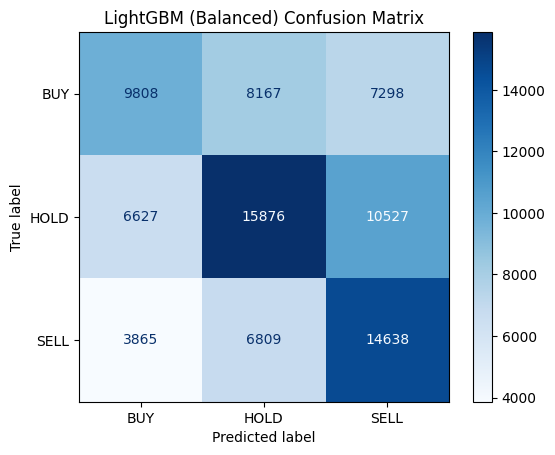

In [99]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test_cls,
    lgbm_balanced_pred,
    display_labels=label_encoder.classes_,
    cmap="Blues"
)

plt.title("LightGBM (Balanced) Confusion Matrix")
plt.show()

In [100]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

In [101]:
from sklearn.model_selection import train_test_split

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    shuffle=False
)

print(X_train_cls.shape)
print(X_test_cls.shape)

(334460, 42)
(83615, 42)


In [102]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(

    objective="multiclass",

    num_class=3,

    n_estimators=500,

    learning_rate=0.05,

    max_depth=6,

    num_leaves=31,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42

)

lgbm.fit(
    X_train_cls,
    y_train_cls
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.055499 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10457
[LightGBM] [Info] Number of data points in the train set: 334460, number of used features: 42
[LightGBM] [Info] Start training from score -1.205848
[LightGBM] [Info] Start training from score -0.913194
[LightGBM] [Info] Start training from score -1.206238
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] N

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [103]:
lgbm_pred = lgbm.predict(X_test_cls)

In [104]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_test_cls, lgbm_pred)

precision = precision_score(
    y_test_cls,
    lgbm_pred,
    average="weighted"
)

recall = recall_score(
    y_test_cls,
    lgbm_pred,
    average="weighted"
)

f1 = f1_score(
    y_test_cls,
    lgbm_pred,
    average="weighted"
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.492005023022185
Precision: 0.4982883386757615
Recall   : 0.492005023022185
F1 Score : 0.4782821858165606


In [105]:
print(
    classification_report(
        y_test_cls,
        lgbm_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

         BUY       0.51      0.30      0.38     25273
        HOLD       0.48      0.68      0.56     33030
        SELL       0.51      0.43      0.47     25312

    accuracy                           0.49     83615
   macro avg       0.50      0.47      0.47     83615
weighted avg       0.50      0.49      0.48     83615



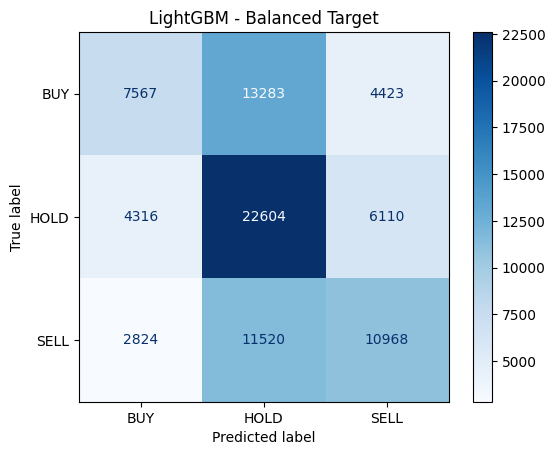

In [106]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test_cls,
    lgbm_pred,
    display_labels=label_encoder.classes_,
    cmap="Blues"
)

plt.title("LightGBM - Balanced Target")

plt.show()

In [107]:
classification_results.loc[len(classification_results)] = [

    "LightGBM (Balanced Target)",

    accuracy,

    precision,

    recall,

    f1

]

classification_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline,0.395025,0.156045,0.395025,0.223716
1,Logistic Regression,0.420594,0.400798,0.420594,0.358727
2,Decision Tree,0.430652,0.418508,0.430652,0.398919
3,Random Forest,0.458650,0.455790,0.458650,0.446825
4,XGBoost,0.479495,0.485024,0.479495,0.460446
5,CatBoost,0.470215,0.472200,0.470215,0.448807
6,LightGBM,0.492005,0.498288,0.492005,0.478282
7,LightGBM (Balanced),0.482234,0.485810,0.482234,0.479839
8,LightGBM (Balanced Target),0.492005,0.498288,0.492005,0.478282


In [108]:
print(y.name)

Target_Signal


In [109]:
print(df["Target_Signal"].value_counts(normalize=True) * 100)

Target_Signal
HOLD    39.999761
SELL    30.000120
BUY     30.000120
Name: proportion, dtype: float64


In [110]:
print(df.shape)

(418075, 49)


In [111]:
print(len(feature_columns))
print(feature_columns)

42
['Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return', 'MA5', 'MA10', 'MA20', 'MA50', 'EMA20', 'EMA12', 'EMA26', 'RSI', 'MACD', 'Signal_Line', 'MACD_Histogram', 'Upper_Band', 'Lower_Band', 'Volatility', 'Lag1', 'Lag2', 'Lag3', 'ATR', 'ADX', 'OBV', 'Stochastic', 'CCI', 'Price_vs_MA20', 'EMA_Diff', 'BB_Width', 'NIFTY_Close', 'NIFTY_Return', 'India_VIX', 'BankNIFTY_Close', 'BankNIFTY_Return', 'Relative_Strength', 'Bank_Relative_Strength', 'Volume_Ratio', 'Gap_Percentage', 'ATR_Percentage', 'Bull_Market']


In [112]:
print(X_train_cls.shape)
print(X_test_cls.shape)

(334460, 42)
(83615, 42)


In [113]:
class_weight=class_weights

In [114]:
print(df["Target_Signal"].value_counts(normalize=True) * 100)

print(df["Target_Signal_Balanced"].value_counts(normalize=True) * 100)

Target_Signal
HOLD    39.999761
SELL    30.000120
BUY     30.000120
Name: proportion, dtype: float64
Target_Signal_Balanced
SELL    34.99994
BUY     34.99994
HOLD    30.00012
Name: proportion, dtype: float64


In [115]:
from sklearn.model_selection import train_test_split

X_train_opt, X_valid, y_train_opt, y_valid = train_test_split(
    X_train_cls,
    y_train_cls,
    test_size=0.2,
    shuffle=False
)

print(X_train_opt.shape)
print(X_valid.shape)

(267568, 42)
(66892, 42)


In [116]:
!pip install optuna


[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip



  Using cached sqlalchemy-2.0.51-cp312-cp312-win_amd64.whl.metadata (9.8 kB)
Using cached sqlalchemy-2.0.51-cp312-cp312-win_amd64.whl (2.1 MB)

   ---------------------------------------- 0/6 [Mako]
   ---------------------------------------- 0/6 [Mako]
   ---------------------------------------- 0/6 [Mako]
   ---------------------------------------- 0/6 [Mako]
   ---------------------------------------- 0/6 [Mako]
   ------ --------------------------------- 1/6 [greenlet]
   ------ --------------------------------- 1/6 [greenlet]
   ------ --------------------------------- 1/6 [greenlet]
   ------ --------------------------------- 1/6 [greenlet]
   ------ --------------------------------- 1/6 [greenlet]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- -----------------

In [117]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [118]:
def objective(trial):

    params = {

        "objective": "multi:softprob",
        "num_class": 3,

        "n_estimators": trial.suggest_int(
            "n_estimators",
            300,
            800
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.1,
            log=True
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            4,
            10
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight",
            1,
            10
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.7,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.7,
            1.0
        ),

        "gamma": trial.suggest_float(
            "gamma",
            0,
            5
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            0,
            5
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            0,
            5
        ),

        "eval_metric": "mlogloss",

        "random_state": 42,

        "n_jobs": 4

    }

    model = XGBClassifier(**params)

    model.fit(
        X_train_opt,
        y_train_opt
    )

    pred = model.predict(X_valid)

    return accuracy_score(
        y_valid,
        pred
    )

In [119]:
study = optuna.create_study(
    direction="maximize"
)

study.optimize(
    objective,
    n_trials=50
)

[I 2026-08-06 16:08:20,906] A new study created in memory with name: no-name-eb9e1cff-28c8-4726-9c0f-4fcddeda2490
[I 2026-08-06 16:08:43,954] Trial 0 finished with value: 0.4721042875082222 and parameters: {'n_estimators': 366, 'learning_rate': 0.08074095950397989, 'max_depth': 4, 'min_child_weight': 1, 'subsample': 0.9097559683330692, 'colsample_bytree': 0.9086391197190288, 'gamma': 2.6304016561377432, 'reg_alpha': 3.964705676273534, 'reg_lambda': 2.6119032309905315}. Best is trial 0 with value: 0.4721042875082222.
[I 2026-08-06 16:09:10,471] Trial 1 finished with value: 0.49804161932667584 and parameters: {'n_estimators': 343, 'learning_rate': 0.056921699892770565, 'max_depth': 9, 'min_child_weight': 2, 'subsample': 0.7387758025554674, 'colsample_bytree': 0.8187314692210055, 'gamma': 3.8442681574821718, 'reg_alpha': 4.685907984537842, 'reg_lambda': 0.3580250705221172}. Best is trial 1 with value: 0.49804161932667584.
[I 2026-08-06 16:09:49,852] Trial 2 finished with value: 0.45782754

In [120]:
print("Best Accuracy:", study.best_value)

print("\nBest Parameters:")

for k, v in study.best_params.items():
    print(f"{k}: {v}")

Best Accuracy: 0.5218860252347067

Best Parameters:
n_estimators: 468
learning_rate: 0.05948227962920965
max_depth: 10
min_child_weight: 7
subsample: 0.8803705090474958
colsample_bytree: 0.9272350042592444
gamma: 0.39380963690364845
reg_alpha: 3.408029820339077
reg_lambda: 1.4436020785394823


In [121]:
best_xgb = XGBClassifier(

    objective="multi:softprob",

    num_class=3,

    eval_metric="mlogloss",

    random_state=42,

    **study.best_params

)

best_xgb.fit(
    X_train_cls,
    y_train_cls
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9272350042592444
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

In [137]:
xgb_best_params = study.best_params.copy()
best_params = study.best_params

print(best_params)

{'n_estimators': 923, 'learning_rate': 0.04669099459788054, 'num_leaves': 89, 'max_depth': 12, 'min_child_samples': 77, 'subsample': 0.7696229432132959, 'colsample_bytree': 0.6681045530711367, 'reg_alpha': 3.688664340010877, 'reg_lambda': 3.526373734080299, 'min_split_gain': 0.2400933480053825}


In [122]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

pred = best_xgb.predict(X_test_cls)

accuracy = accuracy_score(
    y_test_cls,
    pred
)

precision = precision_score(
    y_test_cls,
    pred,
    average="weighted"
)

recall = recall_score(
    y_test_cls,
    pred,
    average="weighted"
)

f1 = f1_score(
    y_test_cls,
    pred,
    average="weighted"
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print(
    classification_report(
        y_test_cls,
        pred,
        target_names=label_encoder.classes_
    )
)

Accuracy : 0.5244633139986844
Precision: 0.5297885105130844
Recall   : 0.5244633139986844
F1 Score : 0.5201917815010185
              precision    recall  f1-score   support

         BUY       0.55      0.39      0.46     25273
        HOLD       0.50      0.63      0.55     33030
        SELL       0.56      0.52      0.54     25312

    accuracy                           0.52     83615
   macro avg       0.53      0.51      0.52     83615
weighted avg       0.53      0.52      0.52     83615



In [123]:
classification_results.loc[len(classification_results)] = [

    "XGBoost (Optuna)",

    accuracy,

    precision,

    recall,

    f1

]

classification_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline,0.395025,0.156045,0.395025,0.223716
1,Logistic Regression,0.420594,0.400798,0.420594,0.358727
2,Decision Tree,0.430652,0.418508,0.430652,0.398919
3,Random Forest,0.458650,0.455790,0.458650,0.446825
4,XGBoost,0.479495,0.485024,0.479495,0.460446
5,CatBoost,0.470215,0.472200,0.470215,0.448807
6,LightGBM,0.492005,0.498288,0.492005,0.478282
7,LightGBM (Balanced),0.482234,0.485810,0.482234,0.479839
8,LightGBM (Balanced Target),0.492005,0.498288,0.492005,0.478282
9,XGBoost (Optuna),0.524463,0.529789,0.524463,0.520192


In [124]:
import optuna
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score

In [125]:
def objective(trial):

    params = {

        "objective": "multiclass",
        "num_class": 3,

        "random_state": 42,

        "n_estimators": trial.suggest_int(
            "n_estimators",
            300,
            1000
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.1,
            log=True
        ),

        "num_leaves": trial.suggest_int(
            "num_leaves",
            20,
            200
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            12
        ),

        "min_child_samples": trial.suggest_int(
            "min_child_samples",
            5,
            100
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            0,
            5
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            0,
            5
        ),

        "min_split_gain": trial.suggest_float(
            "min_split_gain",
            0,
            1
        ),

        "verbosity": -1,

        "n_jobs": 4
    }

    model = LGBMClassifier(**params)

    model.fit(
        X_train_opt,
        y_train_opt
    )

    pred = model.predict(X_valid)

    return accuracy_score(
        y_valid,
        pred
    )

In [126]:
study = optuna.create_study(
    direction="maximize"
)

study.optimize(
    objective,
    n_trials=50
)

[I 2026-08-06 17:26:15,959] A new study created in memory with name: no-name-689cc709-74f4-4bc9-8fcb-7021097e4499
[I 2026-08-06 17:26:42,003] Trial 0 finished with value: 0.5083866531124798 and parameters: {'n_estimators': 819, 'learning_rate': 0.04790860251420916, 'num_leaves': 76, 'max_depth': 9, 'min_child_samples': 5, 'subsample': 0.6275074374169548, 'colsample_bytree': 0.7389350413718445, 'reg_alpha': 1.8247148693556658, 'reg_lambda': 4.275404627098951, 'min_split_gain': 0.9931877978767308}. Best is trial 0 with value: 0.5083866531124798.
[I 2026-08-06 17:27:20,801] Trial 1 finished with value: 0.5153531065000299 and parameters: {'n_estimators': 380, 'learning_rate': 0.04295679347207554, 'num_leaves': 173, 'max_depth': 12, 'min_child_samples': 8, 'subsample': 0.860982578396434, 'colsample_bytree': 0.8977601915491522, 'reg_alpha': 2.1932885670227003, 'reg_lambda': 3.648685481405452, 'min_split_gain': 0.347382033959035}. Best is trial 1 with value: 0.5153531065000299.
[I 2026-08-06 

In [128]:
print("Best Validation Accuracy:", study.best_value)

print("\nBest Parameters:\n")

for k, v in study.best_params.items():
    print(f"{k}: {v}")

Best Validation Accuracy: 0.5230969323685941

Best Parameters:

n_estimators: 923
learning_rate: 0.04669099459788054
num_leaves: 89
max_depth: 12
min_child_samples: 77
subsample: 0.7696229432132959
colsample_bytree: 0.6681045530711367
reg_alpha: 3.688664340010877
reg_lambda: 3.526373734080299
min_split_gain: 0.2400933480053825


In [129]:
best_lgbm = LGBMClassifier(

    objective="multiclass",

    num_class=3,

    random_state=42,

    verbosity=-1,

    **study.best_params

)

best_lgbm.fit(
    X_train_cls,
    y_train_cls
)

,boosting_type,'gbdt'
,num_leaves,89
,max_depth,12
,learning_rate,0.04669099459788054
,n_estimators,923
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,None
,min_split_gain,0.2400933480053825
,min_child_weight,0.001
,min_child_samples,77


In [130]:
pred = best_lgbm.predict(X_test_cls)

accuracy = accuracy_score(y_test_cls, pred)

precision = precision_score(
    y_test_cls,
    pred,
    average="weighted"
)

recall = recall_score(
    y_test_cls,
    pred,
    average="weighted"
)

f1 = f1_score(
    y_test_cls,
    pred,
    average="weighted"
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print(
    classification_report(
        y_test_cls,
        pred,
        target_names=label_encoder.classes_
    )
)

Accuracy : 0.5214973389941996
Precision: 0.529551740466524
Recall   : 0.5214973389941996
F1 Score : 0.5152388574131049
              precision    recall  f1-score   support

         BUY       0.55      0.37      0.44     25273
        HOLD       0.49      0.65      0.56     33030
        SELL       0.56      0.50      0.53     25312

    accuracy                           0.52     83615
   macro avg       0.53      0.51      0.51     83615
weighted avg       0.53      0.52      0.52     83615



In [131]:
classification_results.loc[len(classification_results)] = [

    "LightGBM (Optuna)",

    accuracy,

    precision,

    recall,

    f1

]

classification_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline,0.395025,0.156045,0.395025,0.223716
1,Logistic Regression,0.420594,0.400798,0.420594,0.358727
2,Decision Tree,0.430652,0.418508,0.430652,0.398919
3,Random Forest,0.458650,0.455790,0.458650,0.446825
4,XGBoost,0.479495,0.485024,0.479495,0.460446
5,CatBoost,0.470215,0.472200,0.470215,0.448807
6,LightGBM,0.492005,0.498288,0.492005,0.478282
7,LightGBM (Balanced),0.482234,0.485810,0.482234,0.479839
8,LightGBM (Balanced Target),0.492005,0.498288,0.492005,0.478282
9,XGBoost (Optuna),0.524463,0.529789,0.524463,0.520192


In [136]:
lgbm_best_params = study.best_params.copy()

In [132]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [134]:
xgb_stack = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    **study.best_params      # XGBoost Optuna parameters
)

lgbm_stack = LGBMClassifier(
    objective="multiclass",
    num_class=3,
    random_state=42,
    verbosity=-1,
    **study.best_params  # <-- LightGBM Optuna study
)

In [140]:
print(study.best_params)

{'n_estimators': 923, 'learning_rate': 0.04669099459788054, 'num_leaves': 89, 'max_depth': 12, 'min_child_samples': 77, 'subsample': 0.7696229432132959, 'colsample_bytree': 0.6681045530711367, 'reg_alpha': 3.688664340010877, 'reg_lambda': 3.526373734080299, 'min_split_gain': 0.2400933480053825}


In [141]:
from lightgbm import LGBMClassifier

best_lgbm = LGBMClassifier(
    objective="multiclass",
    num_class=3,
    random_state=42,
    verbosity=-1,
    **study.best_params
)

best_lgbm.fit(
    X_train_cls,
    y_train_cls
)

,boosting_type,'gbdt'
,num_leaves,89
,max_depth,12
,learning_rate,0.04669099459788054
,n_estimators,923
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,None
,min_split_gain,0.2400933480053825
,min_child_weight,0.001
,min_child_samples,77


In [142]:
import joblib

joblib.dump(
    best_lgbm,
    "../models/best_lightgbm_optuna.pkl"
)

print("LightGBM Optuna model saved successfully!")

LightGBM Optuna model saved successfully!


In [143]:
best_xgb

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6681045530711367
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

In [144]:
import joblib

joblib.dump(best_xgb, "../models/best_xgboost_optuna.pkl")

print("XGBoost Optuna model saved successfully!")

XGBoost Optuna model saved successfully!


In [145]:
type(best_lgbm)

lightgbm.sklearn.LGBMClassifier

In [146]:
type(best_xgb)

xgboost.sklearn.XGBClassifier

In [147]:
import joblib

joblib.dump(label_encoder, "../models/label_encoder.pkl")

['../models/label_encoder.pkl']